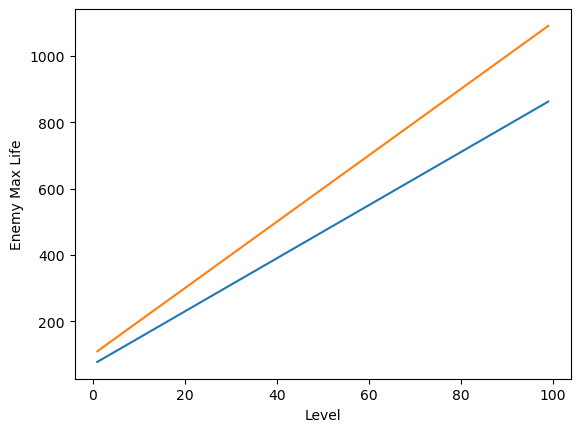

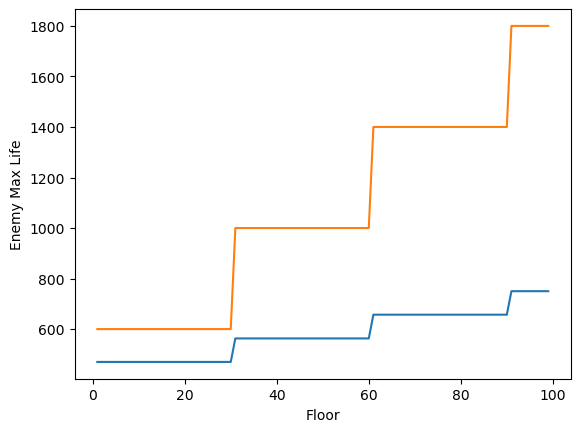

In [36]:
import matplotlib.pyplot as plt

EMY_LIFE = [
    5, 0, -50, 100, 10, 10, 0, 30, 10, 100,
]

EMY_LIFE2 = [
    100, 120, 120, 200, 170, 200, 230, 280, 300, 400,
]

emy_typ = 0
floor = 10
lev = 5
geta = 0

emy_lifemax_list = []
emy_lifemax_new_list = []
for lev in range(1, 100):
    emy_lifemax_new = EMY_LIFE2 [emy_typ ] + lev*10 + 400*(( floor -1 )//30)
    emy_lifemax_new_list.append(emy_lifemax_new)
    emy_lifemax = int ((73 *(emy_typ +1 )+EMY_LIFE [emy_typ ])*(1.2 *((floor -1 )//30 )+1 ))+(lev -1 )*8 +geta *3 
    emy_lifemax_list.append(emy_lifemax)

plt.plot(range(1, 100), emy_lifemax_list)
plt.plot(range(1, 100), emy_lifemax_new_list)
plt.xlabel('Level')
plt.ylabel('Enemy Max Life')
plt.show()

lev = 50

emy_lifemax_list = []
emy_lifemax_new_list = []
for floor in range(1, 100):
    emy_lifemax_new = EMY_LIFE2 [emy_typ ] + lev*10 + 400*((floor -1 )//30)
    emy_lifemax_new_list.append(emy_lifemax_new)
    emy_lifemax = int ((73 *(emy_typ +1 )+EMY_LIFE [emy_typ ])*(1.2 *((floor -1 )//30 )+1 ))+(lev -1 )*8 +geta *3 
    emy_lifemax_list.append(emy_lifemax)

plt.plot(range(1, 100), emy_lifemax_list)
plt.plot(range(1, 100), emy_lifemax_new_list)
plt.xlabel('Floor')
plt.ylabel('Enemy Max Life')
plt.show()

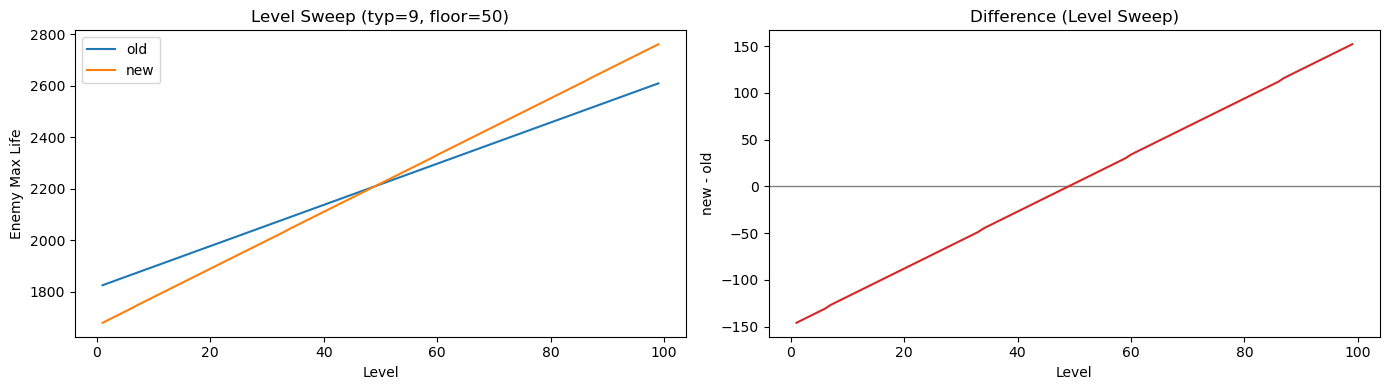

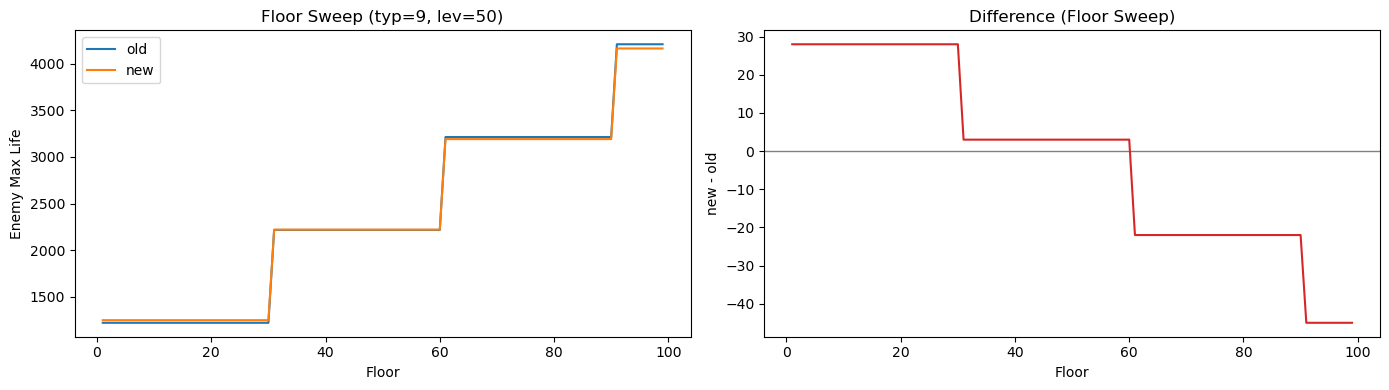

In [59]:
# 旧式と提案式（emy_lifemax_new）の比較 + 差分グラフ
# 前のセルで定義した EMY_LIFE, EMY_LIFE2, emy_typ, floor, lev, geta を利用

def emy_lifemax_old(emy_typ, floor, lev, geta=0):
    return int((73 * (emy_typ + 1) + EMY_LIFE[emy_typ]) * (1.2 * ((floor - 1) // 30) + 1)) + (lev - 1) * 8 + geta * 3


def emy_lifemax_new(emy_typ, floor, lev, geta=0):
    tier = (floor - 1) // 30
    base = max(1, int(2.4 * EMY_LIFE2[emy_typ] - 100))
    floor_mul = 1.0 + 1.2 * tier
    level_mul = 1.0 + 0.12 * (lev - 1) / 99
    level_add = (lev - 1) * 9
    return int(base * floor_mul * level_mul + level_add) + geta * 3

EMY_LIFE = [
    5, 0, -50, 100, 10, 10, 0, 30, 10, 100,
]

EMY_LIFE2 = [
    80, 100, 110, 200, 180, 210, 240, 280, 300, 360,
]

emy_typ = 9
floor = 50
lev = 50
geta = 0

# 1) floor固定で level を変化
levels = list(range(1, 100))
old_by_level = [emy_lifemax_old(emy_typ, floor, lv, geta) for lv in levels]
new_by_level = [emy_lifemax_new(emy_typ, floor, lv, geta) for lv in levels]
diff_by_level = [n - o for o, n in zip(old_by_level, new_by_level)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(levels, old_by_level, label='old')
axes[0].plot(levels, new_by_level, label='new')
axes[0].set_xlabel('Level')
axes[0].set_ylabel('Enemy Max Life')
axes[0].set_title(f'Level Sweep (typ={emy_typ}, floor={floor})')
axes[0].legend()

axes[1].axhline(0, color='gray', linewidth=1)
axes[1].plot(levels, diff_by_level, color='tab:red')
axes[1].set_xlabel('Level')
axes[1].set_ylabel('new - old')
axes[1].set_title('Difference (Level Sweep)')

plt.tight_layout()
plt.show()


# 2) level固定で floor を変化
floors = list(range(1, 100))
old_by_floor = [emy_lifemax_old(emy_typ, fl, lev, geta) for fl in floors]
new_by_floor = [emy_lifemax_new(emy_typ, fl, lev, geta) for fl in floors]
diff_by_floor = [n - o for o, n in zip(old_by_floor, new_by_floor)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(floors, old_by_floor, label='old')
axes[0].plot(floors, new_by_floor, label='new')
axes[0].set_xlabel('Floor')
axes[0].set_ylabel('Enemy Max Life')
axes[0].set_title(f'Floor Sweep (typ={emy_typ}, lev={lev})')
axes[0].legend()

axes[1].axhline(0, color='gray', linewidth=1)
axes[1].plot(floors, diff_by_floor, color='tab:red')
axes[1].set_xlabel('Floor')
axes[1].set_ylabel('new - old')
axes[1].set_title('Difference (Floor Sweep)')

plt.tight_layout()
plt.show()



In [ ]:
EMY_APRO = [
    1, 1, 1, 0.9, 0.8, 1, 0.8, 1, 0.6, 1,
    0.9, 1.1, 1.2, 1, 1, 1, 1, 1, 0.9, 1, 1.2, 1, 0.9,
]

EMY_MPRO = [
    1, 1, 1, 1, 1.1, 1, 1, 0.9, 1.1, 1,
    1.1, 0.8, 0.4, 1.1, 1, 1, 1, 1, 1.1, 1, 1, 0.8, 1,
]